<div dir='rtl'>

# 02 — از یک ویژگی به چند ویژگی

در فصل قبل یاد گرفتیم یک مدل خطی ساده چگونه از داده یاد می‌گیرد.
مدل ما فقط یک ورودی داشت:

</div>

$$
y = wx + b
$$

<div dir='rtl'>

اما بیشتر مسائل واقعی فقط با یک ویژگی توصیف نمی‌شوند.
در این فصل مدل را گسترش می‌دهیم تا بتواند هم‌زمان چند ویژگی را دریافت کند.

**هدف فصل:** در پایان بتوانیم یک Linear Regression چندویژگی را از صفر بسازیم و ببینیم این ایده چگونه ما را به مفهوم نورون نزدیک می‌کند.

</div>


<div dir='rtl'>

## 2.1 — چرا یک ویژگی کافی نیست؟

فرض کنید می‌خواهیم قیمت یک خانه را تخمین بزنیم.
فقط مساحت خانه اطلاعات کاملی به ما نمی‌دهد. تعداد اتاق‌ها، سن بنا و عوامل دیگر هم می‌توانند روی قیمت اثر بگذارند.

پس به‌جای یک ورودی، چند ویژگی داریم:

</div>

```text
x1 = مساحت
x2 = تعداد اتاق
x3 = سن بنا
```

<div dir='rtl'>

مدل باید از همه این اطلاعات به‌صورت هم‌زمان استفاده کند.

</div>


In [1]:
# داده‌ای که در این فصل استفاده می‌کنیم
# خروجی دقیقاً از رابطه زیر ساخته شده است:
# y = 3*x1 + 2*x2 + 5

X = [
    [1, 1],
    [2, 1],
    [1, 3],
    [3, 2],
    [4, 1],
    [2, 4],
    [5, 3],
    [4, 5],
]

Y = [11, 13, 14, 18, 19, 19, 26, 27]

print('تعداد نمونه‌ها:', len(X))
print('تعداد ویژگی‌ها در هر نمونه:', len(X[0]))
print('اولین نمونه:', X[0])
print('خروجی اولین نمونه:', Y[0])


تعداد نمونه‌ها: 8
تعداد ویژگی‌ها در هر نمونه: 2
اولین نمونه: [1, 1]
خروجی اولین نمونه: 11


<div dir='rtl'>

## 2.2 — از چند عدد به یک بردار

هر نمونه را می‌توان به‌صورت یک بردار دید:

</div>

$$
\mathbf{x} = [x_1, x_2]
$$

<div dir='rtl'>

برای مثال، نمونه اول ما برابر است با:

</div>

$$
[1, 1]
$$

<div dir='rtl'>

مدل چندویژگی نیز به شکل زیر نوشته می‌شود:

</div>

$$
y_{pred} = w_1x_1 + w_2x_2 + b
$$

<div dir='rtl'>

هر ویژگی یک وزن دارد. وزن مشخص می‌کند آن ویژگی چقدر روی خروجی اثر می‌گذارد.

</div>


<div dir='rtl'>

## 2.3 — پیش‌بینی با چند ویژگی

اول مفهوم را بدون هیچ کتابخانه‌ای پیاده‌سازی می‌کنیم.

</div>


In [2]:
w = [0.0, 0.0]
b = 0.0

def predict_one(sample, weights, bias):
    total = 0.0
    for j in range(len(weights)):
        total += weights[j] * sample[j]
    return total + bias

predictions = [predict_one(sample, w, b) for sample in X]

for i in range(3):
    print(f'X={X[i]} -> prediction={predictions[i]:.2f}, actual={Y[i]}')


X=[1, 1] -> prediction=0.00, actual=11
X=[2, 1] -> prediction=0.00, actual=13
X=[1, 3] -> prediction=0.00, actual=14


<div dir='rtl'>

## 2.4 — Dot Product را خودمان بسازیم

عبارت

</div>

$$
w_1x_1 + w_2x_2
$$

<div dir='rtl'>

در جبر خطی همان **Dot Product** بین دو بردار است.

برای یادگیری بهتر، فعلاً آن را با حلقه معمولی می‌نویسیم تا دقیقاً ببینیم چه اتفاقی می‌افتد.

</div>


In [3]:
def dot_product(a, b):
    if len(a) != len(b):
        raise ValueError('بردارها باید هم‌اندازه باشند.')

    result = 0.0
    for i in range(len(a)):
        result += a[i] * b[i]
    return result

example_weights = [3, 2]
example_sample = [4, 5]

print('Dot Product =', dot_product(example_weights, example_sample))
print('Prediction =', dot_product(example_weights, example_sample) + 5)


Dot Product = 22.0
Prediction = 27.0


<div dir='rtl'>

## 2.5 — Loss هنوز همان مسئله قبلی است

با اضافه شدن ویژگی‌ها، هدف ما عوض نشده است.
هنوز می‌خواهیم پیش‌بینی مدل به مقدار واقعی نزدیک باشد.

از همان Mean Squared Error استفاده می‌کنیم:

</div>

$$
MSE = 
rac{1}{n}\sum_{i=1}^{n}(y_{pred}^{(i)} - y^{(i)})^2
$$

In [4]:
def mse(y_true, y_pred):
    if len(y_true) != len(y_pred):
        raise ValueError('طول y_true و y_pred باید برابر باشد.')
    return sum((y_pred[i] - y_true[i]) ** 2 for i in range(len(y_true))) / len(y_true)

print('Initial MSE:', mse(Y, predictions))


Initial MSE: 367.125


<div dir='rtl'>

## 2.6 — Gradient هر وزن را چطور پیدا کنیم؟

در فصل قبل یک وزن داشتیم و فقط `dw` را پیدا می‌کردیم.

حالا دو وزن داریم، بنابراین دو گرادیان داریم:

</div>

$$
dw_1 = 
rac{2}{n}\sum (y_{pred}-y)x_1
$$

$$
dw_2 = 
rac{2}{n}\sum (y_{pred}-y)x_2
$$

<div dir='rtl'>

و برای بایاس:

</div>

$$
db = 
rac{2}{n}\sum (y_{pred}-y)
$$

<div dir='rtl'>

نکته مهم این است که هر وزن بر اساس همان ویژگی‌ای که به آن متصل است، گرادیان خودش را دریافت می‌کند.

</div>


In [5]:
def compute_gradients(X, Y, weights, bias):
    n = len(X)
    predictions = [predict_one(sample, weights, bias) for sample in X]

    dw = [0.0] * len(weights)

    for j in range(len(weights)):
        dw[j] = (2 / n) * sum(
            (predictions[i] - Y[i]) * X[i][j]
            for i in range(n)
        )

    db = (2 / n) * sum(predictions[i] - Y[i] for i in range(n))
    return dw, db

weights = [0.0, 0.0]
bias = 0.0

dw, db = compute_gradients(X, Y, weights, bias)
print('dw =', [round(value, 4) for value in dw])
print('db =', round(db, 4))


dw = [-114.25, -102.5]
db = -36.75


<div dir='rtl'>

## 2.7 — آموزش مدل چندویژگی

در هر epoch همان چرخه قبلی را تکرار می‌کنیم:

<div align='center'>

```text
Prediction
    ↓
Loss / Gradient
    ↓
Update weights and bias
    ↓
Repeat
```

</div>

تنها تفاوت این است که حالا به‌جای یک وزن، چند وزن داریم.

</div>


In [6]:
def train(X, Y, learning_rate=0.03, epochs=1500):
    weights = [0.0] * len(X[0])
    bias = 0.0

    history = {
        'epoch': [],
        'loss': [],
        'weights': [],
        'bias': []
    }

    for epoch in range(epochs):
        predictions = [predict_one(sample, weights, bias) for sample in X]
        loss = mse(Y, predictions)
        dw, db = compute_gradients(X, Y, weights, bias)

        for j in range(len(weights)):
            weights[j] -= learning_rate * dw[j]

        bias -= learning_rate * db

        history['epoch'].append(epoch)
        history['loss'].append(loss)
        history['weights'].append(weights.copy())
        history['bias'].append(bias)

    return weights, bias, history

weights, bias, history = train(X, Y)

print('Final weights:', [round(value, 4) for value in weights])
print('Final bias:', round(bias, 4))
print('Final loss:', round(history['loss'][-1], 6))


Final weights: [2.9052, 1.93]
Final bias: 5.5609
Final loss: 0.075498


<div dir='rtl'>

## 2.8 — Visualization: Loss و وزن‌ها

دو سؤال را هم‌زمان بررسی می‌کنیم:

1. آیا Loss کم می‌شود؟
2. آیا وزن‌ها به ضرایب واقعی رابطه نزدیک می‌شوند؟

در این مثال، رابطه واقعی ما این بود:

</div>

$$
y = 3x_1 + 2x_2 + 5
$$

<div dir='rtl'>

پس انتظار داریم وزن‌ها به `3` و `2` و بایاس به `5` نزدیک شوند.

</div>


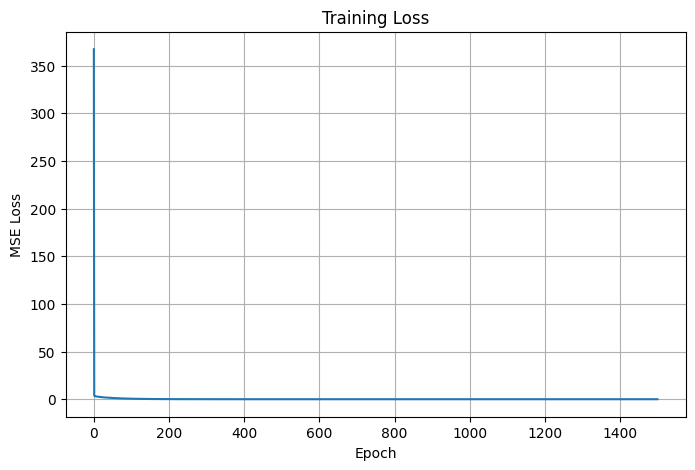

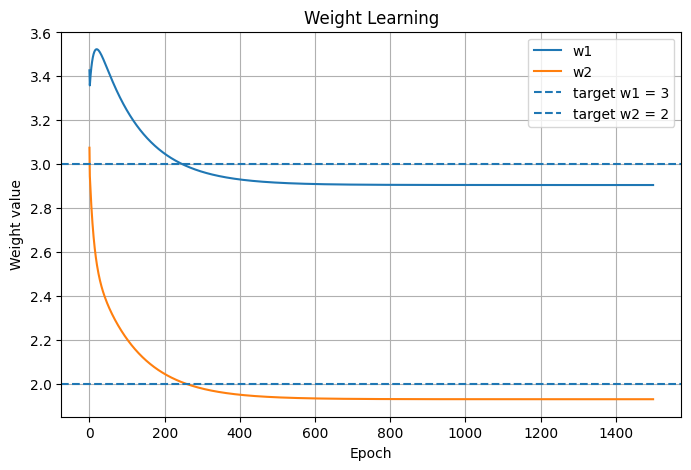

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['loss'])
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

weight_history = list(zip(*history['weights']))

plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], weight_history[0], label='w1')
plt.plot(history['epoch'], weight_history[1], label='w2')
plt.axhline(3, linestyle='--', label='target w1 = 3')
plt.axhline(2, linestyle='--', label='target w2 = 2')
plt.xlabel('Epoch')
plt.ylabel('Weight value')
plt.title('Weight Learning')
plt.legend()
plt.grid(True)
plt.show()


<div dir='rtl'>

## 2.9 — یک نکته مهم: ویژگی‌ها باید اطلاعات مستقل بدهند

در فایل قبلی داده‌هایی شبیه این داشتیم:

</div>

```text
[1, 2]
[2, 3]
[3, 4]
[4, 5]
```

<div dir='rtl'>

در همه این نمونه‌ها همیشه:

</div>

```text
x2 = x1 + 1
```

<div dir='rtl'>

وجود داشت. بنابراین مدل نمی‌توانست اثر مستقل دو ویژگی را به‌درستی جدا کند.

این بار داده‌ها را طوری ساخته‌ایم که ویژگی‌ها الگوهای متفاوتی داشته باشند. به همین دلیل مدل می‌تواند ضرایب واقعی را بهتر یاد بگیرد.

این موضوع در پروژه‌های واقعی اهمیت زیادی دارد: **داده خوب فقط داده زیاد نیست؛ ویژگی‌ها باید اطلاعات مفیدی درباره مسئله بدهند.**

</div>


<div dir='rtl'>

## 2.10 — تست روی یک نمونه جدید

حالا یک نمونه را انتخاب می‌کنیم که در داده آموزشی نبود.

</div>


In [8]:
new_sample = [6, 4]
prediction = predict_one(new_sample, weights, bias)
actual = 3 * new_sample[0] + 2 * new_sample[1] + 5

print('New sample:', new_sample)
print(f'Prediction: {prediction:.4f}')
print(f'Ideal value: {actual}')
print(f'Absolute error: {abs(prediction - actual):.4f}')


New sample: [6, 4]
Prediction: 30.7118
Ideal value: 31
Absolute error: 0.2882


<div dir='rtl'>

## 2.11 — این مدل چه ربطی به یک نورون دارد؟

تا اینجا محاسبه اصلی مدل ما این است:

</div>

$$
z = w_1x_1 + w_2x_2 + b
$$

<div dir='rtl'>

این عبارت را نگه دارید؛ چون در فصل‌های بعد دقیقاً دوباره با آن روبه‌رو می‌شویم.

اگر به‌جای خروجی خطی، یک تابع دیگر روی `z` اعمال کنیم، به ایده‌ای بسیار نزدیک به یک **Neuron** می‌رسیم:

</div>

$$
y = activation(w_1x_1 + w_2x_2 + b)
$$

<div dir='rtl'>

پس شبکه عصبی ناگهان از آسمان نمی‌آید؛ یکی از ایده‌های پایه آن همین محاسبه ساده است که در این فصل ساختیم.

</div>


<div dir='rtl'>

# جمع‌بندی فصل 2

<div align="center">

```text
چند Feature
    ↓
Vector
    ↓
Weighted Sum
    ↓
y = w1*x1 + w2*x2 + b
    ↓
Loss
    ↓
Gradients
    ↓
Gradient Descent
    ↓
یادگیری چند Weight
```

</div>

در فصل بعد، همین ایده را یک قدم جلوتر می‌بریم و با **Classification، Perceptron و Activation Function** وارد دنیای نورون‌ها می‌شویم.

</div>


<div dir='rtl'>

## Challenge فصل 2

1. رابطه واقعی را از `y = 3*x1 + 2*x2 + 5` به یک رابطه دیگر تغییر بده و ببین وزن‌های مدل چه تغییری می‌کنند.
2. یک ویژگی سوم به داده‌ها اضافه کن.
3. `learning_rate` را چند مقدار مختلف قرار بده و رفتار Loss را مقایسه کن.
4. توضیح بده چرا در این فصل برای هر ویژگی یک `dw` جدا داریم.

</div>
